<a href="https://colab.research.google.com/github/Grzegorz-GG/DissertationPW/blob/main/Experiment37.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from glob import glob
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import wandb
import joblib
import torchvision.transforms as transforms
from torchvision.transforms import v2

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import timm
import matplotlib.pyplot as plt

from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
gt_path = 'train_gt.csv'
wavelength_path = 'wavelengths.csv'

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

output_dir = '/content/test_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

!tar -xzvf /content/drive/MyDrive/test.tar.gz -C {output_dir}

test/
test/77.npz
test/837.npz
test/189.npz
test/63.npz
test/823.npz
test/638.npz
test/610.npz
test/88.npz
test/176.npz
test/162.npz
test/604.npz
test/1145.npz
test/1151.npz
test/348.npz
test/374.npz
test/412.npz
test/406.npz
test/360.npz
test/599.npz
test/1019.npz
test/1031.npz
test/1025.npz
test/228.npz
test/200.npz
test/566.npz
test/572.npz
test/214.npz
test/943.npz
test/957.npz
test/758.npz
test/980.npz
test/994.npz
test/764.npz
test/770.npz
test/771.npz
test/765.npz
test/995.npz
test/981.npz
test/759.npz
test/956.npz
test/942.npz
test/573.npz
test/215.npz
test/201.npz
test/567.npz
test/229.npz
test/1024.npz
test/1030.npz
test/1018.npz
test/598.npz
test/407.npz
test/361.npz
test/375.npz
test/413.npz
test/349.npz
test/1150.npz
test/1144.npz
test/163.npz
test/605.npz
test/89.npz
test/611.npz
test/177.npz
test/639.npz
test/822.npz
test/62.npz
test/836.npz
test/76.npz
test/188.npz
test/60.npz
test/820.npz
test/74.npz
test/834.npz
test/48.npz
test/808.npz
test/149.npz
test/607.npz
test/

In [6]:
output_dir = '/content/train_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

!tar -xzvf /content/drive/MyDrive/train.tar.gz -C {output_dir}

train/
train/77.npz
train/837.npz
train/189.npz
train/1409.npz
train/63.npz
train/823.npz
train/1347.npz
train/1421.npz
train/1435.npz
train/1353.npz
train/638.npz
train/610.npz
train/1384.npz
train/88.npz
train/176.npz
train/162.npz
train/1390.npz
train/604.npz
train/1179.npz
train/1623.npz
train/1145.npz
train/1151.npz
train/1637.npz
train/348.npz
train/374.npz
train/1186.npz
train/412.npz
train/406.npz
train/1192.npz
train/360.npz
train/599.npz
train/1019.npz
train/1031.npz
train/1025.npz
train/228.npz
train/200.npz
train/566.npz
train/572.npz
train/214.npz
train/943.npz
train/1569.npz
train/957.npz
train/1233.npz
train/1555.npz
train/1541.npz
train/1227.npz
train/758.npz
train/980.npz
train/994.npz
train/764.npz
train/1596.npz
train/1582.npz
train/770.npz
train/1583.npz
train/771.npz
train/765.npz
train/1597.npz
train/995.npz
train/981.npz
train/759.npz
train/1540.npz
train/1226.npz
train/1232.npz
train/1554.npz
train/956.npz
train/942.npz
train/1568.npz
train/573.npz
train/215.npz

In [7]:
gt_df = pd.read_csv(gt_path)
wavelength_df = pd.read_csv(wavelength_path)

In [8]:
def load_data(directory: str):
    data = []

    all_files = np.array(
        sorted(
            glob(os.path.join(directory, "*.npz")),
            key=lambda x: int(os.path.basename(x).replace(".npz", "")),
        )
    )

    for file_name in all_files:
        with np.load(file_name) as npz:
            # Create masked array
            raw_arr = np.ma.MaskedArray(
                data=npz['data'],
                mask=npz['mask']
            )

            # Raw tensor (KEEP values as-is)
            img_tensor = torch.as_tensor(raw_arr.data, dtype=torch.float32)

            # Mask: 1 = valid, 0 = invalid
            mask = ~torch.as_tensor(raw_arr.mask)

        # Store BOTH
        data.append((img_tensor, mask))

    return data

In [9]:
def load_gt(file_path: str):
    """Load labels for train set from the ground truth file.
    Args:
        file_path (str): Path to the ground truth .csv file.
    Returns:
        [type]: 2D numpy array with soil properties levels
    """
    gt_file = pd.read_csv(file_path)
    labels = gt_file[["P", "K", "Mg", "pH"]].values
    return labels

In [10]:
X_train_full_data = load_data("/content/train_data/train")
y_train = load_gt("train_gt.csv")

In [11]:
original_spectral_channels = X_train_full_data[0][0].shape[0]
print(f"Original spectral channels: {original_spectral_channels}")
reduced_spectral_channels = 3 # Number of channels after 1x1 convolution

Original spectral channels: 150


In [12]:
import numpy as np
from sklearn.model_selection import train_test_split

# -----------------------
# Split into train, val, test
# -----------------------

# Create an array of indices for X_train_full_data
original_indices = np.arange(len(X_train_full_data))

# First, split off test set (20%)
X_temp, X_test, y_temp, y_test, temp_indices, test_indices = train_test_split(
    X_train_full_data, y_train, original_indices, test_size=0.2, random_state=93
)

# Then, split remaining 80% into train/val (20% val of original, means 25% of X_temp)
X_train_final, X_val, y_train_final, y_val, train_indices, val_indices = train_test_split(
    X_temp, y_temp, temp_indices, test_size=0.25, random_state=93
)

print(f"Train patches: {len(X_train_final)}")
print(f"Validation patches: {len(X_val)}")
print(f"Test patches: {len(X_test)}")

Train patches: 1038
Validation patches: 347
Test patches: 347


In [13]:
def _pad_to_size_static(x, mask, size=(224, 224)):
    _, h, w = x.shape
    th, tw = size

    # ---- STEP 1: CROP if too large ----
    if h > th:
        start_h = (h - th) // 2
        x = x[:, start_h:start_h + th, :]
        mask = mask[:, start_h:start_h + th, :]
        h = th

    if w > tw:
        start_w = (w - tw) // 2
        x = x[:, :, start_w:start_w + tw]
        mask = mask[:, :, start_w:start_w + tw]
        w = tw

    # ---- STEP 2: PAD if too small ----
    pad_h = th - h
    pad_w = tw - w

    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    x = F.pad(x, (pad_left, pad_right, pad_top, pad_bottom), value=0)
    mask = F.pad(mask, (pad_left, pad_right, pad_top, pad_bottom), value=0)

    return x, mask

def calculate_global_stats(X_data, pad_function):
    print("Calculating global per-channel means and std deviations from training data...")

    # Initialize lists to store valid pixel values for each channel
    num_channels = X_data[0][0].shape[0]
    channel_data = [[] for _ in range(num_channels)]

    for x_item, mask_item in tqdm(X_data, desc="Processing X_data for global stats"):
        # Pad to consistent size first, as this affects the mask and values
        x_padded, mask_padded = pad_function(x_item, mask_item)

        # Extract valid pixels per channel
        for c in range(num_channels):
            valid_c_pixels = x_padded[c][mask_padded[c]].cpu().numpy()
            channel_data[c].extend(valid_c_pixels)

    # Calculate global mean and std for each channel
    global_means = torch.tensor([np.mean(c_data) for c_data in channel_data], dtype=torch.float32)
    global_stds = torch.tensor([np.std(c_data) for c_data in channel_data], dtype=torch.float32)

    print(f"Global Means (per channel): {global_means}")
    print(f"Global Std Devs (per channel): {global_stds}")
    return global_means, global_stds

# Call the new function to calculate global_means and global_stds
global_means, global_stds = calculate_global_stats(X_train_final, _pad_to_size_static)


Calculating global per-channel means and std deviations from training data...


Processing X_data for global stats: 100%|██████████| 1038/1038 [01:01<00:00, 16.93it/s]


Global Means (per channel): tensor([ 335.9208,  335.9069,  331.7341,  338.8154,  347.5788,  364.8742,
         374.7284,  375.6686,  377.9044,  380.5071,  385.3977,  393.0356,
         398.9632,  414.6352,  429.2801,  437.0627,  446.8707,  456.7486,
         466.4856,  467.3013,  475.4815,  490.8455,  513.5848,  538.7640,
         552.9874,  561.9896,  574.5370,  582.4282,  594.5684,  603.2874,
         615.0793,  623.9404,  630.4449,  633.6147,  633.7065,  634.5967,
         641.4842,  646.1486,  654.0912,  663.0143,  672.3674,  677.5461,
         681.8059,  684.6404,  691.3089,  698.3139,  701.8467,  701.3326,
         704.2673,  707.9794,  713.8121,  717.9084,  720.1819,  720.1807,
         724.6096,  729.8087,  735.5328,  749.8523,  756.5817,  753.4753,
         745.9611,  736.2238,  730.0534,  727.6396,  731.4945,  725.1307,
         721.3279,  725.2855,  735.6935,  767.1006,  809.9006,  859.7301,
         909.7721,  953.6044,  989.5249, 1022.1210, 1063.2218, 1101.7101,
        11

In [14]:
global_means.shape

torch.Size([150])

In [15]:
global_stds.shape

torch.Size([150])

In [16]:
# -------------------------------
# Scale labels
# -------------------------------
scaler_y = StandardScaler()
y_train_final_scaled = scaler_y.fit_transform(y_train_final)
y_val_scaled   = scaler_y.transform(y_val)
y_test_scaled  = scaler_y.transform(y_test)
joblib.dump(scaler_y, "scaler_labels.pkl")
print("Label scaler saved.")

Label scaler saved.


In [17]:
import torch
from torch.utils.data import Dataset
import torch.nn.functional as F
from torchvision.transforms import v2


class RandomSpectralDrop:
    """Zero out random spectral channels to prevent over-reliance on specific bands."""
    def __init__(self, drop_prob=0.05):
        self.drop_prob = drop_prob

    def __call__(self, x):
        keep = torch.bernoulli(torch.ones(x.shape[0]) * (1 - self.drop_prob))
        return x * keep.view(-1, 1, 1)


class NPZDataset(Dataset):
    def __init__(self, tensor_list, labels = None, augment=True, size=(224, 224), global_means=None, global_stds=None):
        """
        tensor_list: list of tuples -> [(x, mask), ...]
                     x: (C, H, W)
                     mask: (C, H, W) with 1=valid, 0=invalid
        """
        self.tensor_list = tensor_list
        self.labels = labels
        self.augment = augment
        self.size = size
        self.global_means = global_means
        self.global_stds = global_stds

        self.transform_aug = v2.Compose([
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomVerticalFlip(p=0.5),
            v2.RandomRotation(degrees=(-180, 180)), # Changed to RandomRotation for continuous angles
            RandomSpectralDrop(drop_prob=0.05),
            #v2.RandomApply([v2.GaussianNoise(mean=0., sigma=0.01)], p=0.2)
        ])

        #self.transform_basic = v2.Compose([])

    def __len__(self):
        return len(self.tensor_list)

    # ══ Crop (if too large) + Pad (if too small)
    def pad_to_size(self, x, mask):
        _, h, w = x.shape
        th, tw = self.size

        # ---- STEP 1: CROP if too large ----
        if h > th:
            start_h = (h - th) // 2
            x = x[:, start_h:start_h + th, :]
            mask = mask[:, start_h:start_h + th, :]
            h = th

        if w > tw:
            start_w = (w - tw) // 2
            x = x[:, :, start_w:start_w + tw]
            mask = mask[:, :, start_w:start_w + tw]
            w = tw

        # ---- STEP 2: PAD if too small ----
        pad_h = th - h
        pad_w = tw - w

        pad_top = pad_h // 2
        pad_bottom = pad_h - pad_top
        pad_left = pad_w // 2
        pad_right = pad_w - pad_left

        x = F.pad(x, (pad_left, pad_right, pad_top, pad_bottom), value=0)
        mask = F.pad(mask, (pad_left, pad_right, pad_top, pad_bottom), value=0)

        return x, mask

    def normalize_with_mask(self, x, mask):
        # mask: 1 = valid, 0 = invalid
        if self.global_means is not None and self.global_stds is not None:
            # Use global per-channel statistics for normalization
            # Reshape global_means and global_stds to (C, 1, 1) for broadcasting
            x_norm = (x - self.global_means.to(x.device).view(-1, 1, 1)) / \
                     (self.global_stds.to(x.device).view(-1, 1, 1) + 1e-6)

        # ---- IMPORTANT: keep invalid pixels neutral ----
        x_norm = x_norm * mask

        return x_norm

    def __getitem__(self, idx):
        x, mask = self.tensor_list[idx]

        # 1. FIX SIZE FIRST
        x, mask = self.pad_to_size(x, mask)

        # Count valid (non-padded) pixels before augmentation
        num_valid_pixels = mask[0].sum().float()

        # 2. NORMALIZE USING MASK
        x = self.normalize_with_mask(x, mask)

        # 4. AUGMENTATION (only if labels are present, typically for training/validation)
        if self.augment and self.labels is not None:
            x = self.transform_aug(x)
            x = x * mask  # re-zero invalid pixels corrupted by GaussianNoise

        if self.labels is not None:
            y = torch.tensor(self.labels[idx], dtype=torch.float32)
            return x, num_valid_pixels, y
        else:
            # For submission or inference without labels
            return x, num_valid_pixels


In [18]:
def check_normalized_stats(dataset: NPZDataset, device: torch.device):
    """
    Checks the per-channel mean and standard deviation of data AFTER normalization.
    It re-applies padding and normalization from the dataset's methods to raw data
    and then calculates statistics only on valid (non-masked) normalized pixels.
    """
    print("\nChecking per-channel means and std deviations for normalized data...")

    num_channels = dataset.tensor_list[0][0].shape[0]
    channel_data_normalized = [[] for _ in range(num_channels)]

    for idx in tqdm(range(len(dataset)), desc="Processing dataset for normalized stats"): # Iterate through the original data for accurate stats
        x_raw, mask_raw = dataset.tensor_list[idx]

        # Apply padding using the dataset's method
        x_padded, mask_padded = dataset.pad_to_size(x_raw, mask_raw)

        # Apply normalization using the dataset's method (which uses global_means/stds)
        x_normalized = dataset.normalize_with_mask(x_padded, mask_padded)

        # Extract valid pixels per channel from the normalized data
        for c in range(num_channels):
            # Ensure mask_padded is also on CPU if x_normalized is on CPU for indexing
            valid_c_pixels = x_normalized[c][mask_padded[c]].cpu().numpy()
            channel_data_normalized[c].extend(valid_c_pixels)

    # Calculate mean and std for each channel from the normalized valid pixels
    means_normalized = torch.tensor([np.mean(c_data) for c_data in channel_data_normalized if len(c_data) > 0], dtype=torch.float32)
    stds_normalized = torch.tensor([np.std(c_data) for c_data in channel_data_normalized if len(c_data) > 0], dtype=torch.float32)

    print(f"Normalized Means (per channel): {means_normalized}")
    print(f"Normalized Std Devs (per channel): {stds_normalized}")
    return means_normalized, stds_normalized

In [19]:
# -----------------------
# Create Dataset and DataLoader with global stats
# -----------------------

train_dataset = NPZDataset(X_train_final, y_train_final_scaled, augment=True, global_means=global_means, global_stds=global_stds)
val_dataset   = NPZDataset(X_val, y_val_scaled, augment=False, global_means=global_means, global_stds=global_stds)
test_dataset  = NPZDataset(X_test, y_test_scaled, augment=False, global_means=global_means, global_stds=global_stds)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)


In [20]:
# Verify normalization for the training dataset
normalized_means_train, normalized_stds_train = check_normalized_stats(train_dataset, device)


Checking per-channel means and std deviations for normalized data...


Processing dataset for normalized stats: 100%|██████████| 1038/1038 [00:55<00:00, 18.61it/s]


Normalized Means (per channel): tensor([-1.6917e-07, -2.1575e-06, -1.6974e-06,  2.2670e-06,  1.0800e-06,
         5.7066e-07,  4.0319e-07, -4.4846e-08,  1.5490e-06,  4.5173e-07,
         1.2925e-06,  9.3070e-07,  8.1305e-07,  2.1447e-06, -8.2540e-07,
        -1.8790e-07, -1.6766e-06,  5.3532e-07, -4.3598e-07, -6.7866e-07,
        -2.6652e-07, -5.8754e-07,  6.0883e-07, -2.4098e-07, -4.4392e-07,
         1.6284e-06,  1.5577e-06,  1.1351e-06, -1.5242e-06,  1.7853e-07,
         2.0067e-07,  4.3541e-07,  1.3372e-06,  6.1394e-07,  5.0949e-07,
         1.0806e-06, -8.7309e-07, -1.1166e-06,  3.9879e-07,  1.9423e-06,
         1.2858e-07,  1.7536e-06, -3.8318e-08,  1.4447e-06,  9.5370e-07,
         2.2599e-06,  1.1839e-06, -6.8121e-07,  4.6039e-07, -1.6355e-06,
         1.3658e-06,  4.2462e-07, -1.7618e-06,  8.8586e-07, -1.2091e-07,
        -7.4309e-07, -6.4346e-07, -6.0287e-07,  3.0470e-07, -1.0786e-06,
         8.2867e-07,  3.7311e-07, -8.2072e-07, -1.2307e-06,  2.6028e-07,
         1.2943e-07

In [21]:
import torch
import torch.nn as nn
import timm

class HyperspectralRegressor(nn.Module):
    def __init__(
        self,
        original_in_channels: int = 150,
        reduced_in_channels: int = 10,
        n_outputs: int = 4,
        backbone_name: str = "efficientnet_b0",
        pretrained: bool = False,
        dropout: float = 0.3,
        regressor: nn.Module = None,
    ):
        """
        original_in_channels: Number of input spectral bands (masked pixels are zero).
        reduced_in_channels: Number of channels after 1x1 convolution.
        n_outputs: Number of regression outputs.
        backbone_name: Name of the model in timm.
        pretrained: Whether to load ImageNet weights (safe only if reduced_in_channels==3).
        """
        super().__init__()

        self.spectral_reducer = nn.Sequential(
            nn.Conv2d(original_in_channels, 32, kernel_size=1, bias=False),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.Conv2d(32, reduced_in_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(reduced_in_channels),
        )

        effective_pretrained = pretrained
        if pretrained and reduced_in_channels != 3:
            effective_pretrained = False

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=effective_pretrained,
            in_chans=reduced_in_channels,
            num_classes=0,
        )

        feat_dim = getattr(self.backbone, "num_features", None)
        if feat_dim is None:
            if hasattr(self.backbone, "fc") and hasattr(self.backbone.fc, "in_features"):
                feat_dim = self.backbone.fc.in_features
            else:
                raise RuntimeError("Backbone features cannot be determined")

        # Use provided regressor or default to the original one
        if regressor is None:

            self.regressor = nn.Sequential(
                nn.Linear(feat_dim + 1, 256),  # +1 for log(valid_pixels) feature
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(256, 64),
                nn.GELU(),
                nn.Dropout(dropout / 2),
                nn.Linear(64, n_outputs),
            )
        else:
            self.regressor = regressor


    def forward(self, x, num_valid_pixels):
        """
        x: (B, original_in_channels, H, W)  -- masked pixels = 0
        num_valid_pixels: (B,) count of valid (non-padded) pixels per patch
        returns: (B, n_outputs)
        """
        x = self.spectral_reducer(x)                                      # (B, reduced_in_channels, H, W)
        features = self.backbone(x)                                       # (B, feat_dim)

        # log1p(50176) ~ 10.8 for a full 224x224 patch, normalize to ~[0,1]
        size_feat = torch.log1p(num_valid_pixels.float()) / 10.0          # (B,)
        features = torch.cat([features, size_feat.unsqueeze(1)], dim=1)  # (B, feat_dim+1)
        out = self.regressor(features)                                    # (B, n_outputs)
        return out

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True


## **Overfitting on one batch**

In [22]:
def overfit_single_batch(
    model: nn.Module,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    x_single: torch.Tensor,
    num_valid_pixels_single: torch.Tensor,
    y_single: torch.Tensor,
    epochs: int = 500,
    device: torch.device = torch.device("cpu")
):
    """
    Performs overfitting of a model on a single batch of data.

    Args:
        model (nn.Module): The model to overfit.
        criterion (nn.Module): The loss function.
        optimizer (optim.Optimizer): The optimizer.
        x_single (torch.Tensor): The input features for the single batch.
        y_single (torch.Tensor): The target labels for the single batch.
        epochs (int): The number of epochs to train for.
        device (torch.device): The device (CPU/GPU) to run the training on.
    """
    print(f"\n--- Starting Overfitting on Single Batch for {epochs} epochs ---")

    x_single = x_single.to(device)
    num_valid_pixels_single = num_valid_pixels_single.to(device)
    y_single = y_single.to(device)

    for epoch_overfit in range(epochs):
        model.train()
        optimizer.zero_grad()

        outputs_overfit = model(x_single, num_valid_pixels_single)
        loss_overfit = criterion(outputs_overfit, y_single)

        loss_overfit.backward()
        optimizer.step()

        if (epoch_overfit + 1) % 10 == 0 or epoch_overfit == 0:
            print(f"Overfit Epoch {epoch_overfit+1}/{epochs} - Loss: {loss_overfit.item():.6f}")

    print("--- Overfitting complete ---")

In [23]:
train_data_single_batch = next(iter(train_loader))

In [24]:
train_data_single_batch[0].shape

torch.Size([32, 150, 224, 224])

In [25]:
train_data_single_batch[1].shape

torch.Size([32])

In [27]:
import torch
import torch.nn as nn
import timm

# Re-initialize a fresh model for overfitting
model_overfit = HyperspectralRegressor(
    reduced_in_channels = 3,   # reduced channels
    n_outputs = 4,      # P, K, Mg, pH
    backbone_name = "maxvit_tiny_tf_224",
    pretrained = True  # Use pre-trained weights
)
model_overfit = model_overfit.to(device)

# Define optimizer and criterion for overfitting

optimizer_overfit = optim.AdamW([
    {"params": model_overfit.spectral_reducer.parameters(), "lr": 1e-3},
    {"params": model_overfit.backbone.parameters(), "lr": 1e-5},
    {"params": model_overfit.regressor.parameters(), "lr": 1e-3},
], weight_decay=1e-4)

#criterion_overfit = nn.SmoothL1Loss(beta=1.0)
criterion_overfit = nn.MSELoss()

# Extract the single batch
x_single, num_valid_pixels_single, y_single = train_data_single_batch

# Move x_single and y_single to the device for consistent usage
x_single = x_single.to(device)
y_single = y_single.to(device)

# Call the overfit_single_batch function
overfit_single_batch(
    model=model_overfit,
    criterion=criterion_overfit,
    optimizer=optimizer_overfit,
    x_single=x_single,
    num_valid_pixels_single=num_valid_pixels_single,
    y_single=y_single,
    epochs=250,
    device=device
)


--- Starting Overfitting on Single Batch for 250 epochs ---
Overfit Epoch 1/250 - Loss: 0.967792
Overfit Epoch 10/250 - Loss: 0.584141
Overfit Epoch 20/250 - Loss: 0.199458
Overfit Epoch 30/250 - Loss: 0.076102
Overfit Epoch 40/250 - Loss: 0.050446
Overfit Epoch 50/250 - Loss: 0.040987
Overfit Epoch 60/250 - Loss: 0.042942
Overfit Epoch 70/250 - Loss: 0.029056
Overfit Epoch 80/250 - Loss: 0.030375
Overfit Epoch 90/250 - Loss: 0.041376
Overfit Epoch 100/250 - Loss: 0.041037
Overfit Epoch 110/250 - Loss: 0.042409
Overfit Epoch 120/250 - Loss: 0.028229
Overfit Epoch 130/250 - Loss: 0.043509
Overfit Epoch 140/250 - Loss: 0.038815
Overfit Epoch 150/250 - Loss: 0.026821
Overfit Epoch 160/250 - Loss: 0.040645
Overfit Epoch 170/250 - Loss: 0.043885
Overfit Epoch 180/250 - Loss: 0.036164
Overfit Epoch 190/250 - Loss: 0.027132
Overfit Epoch 200/250 - Loss: 0.032416
Overfit Epoch 210/250 - Loss: 0.026389
Overfit Epoch 220/250 - Loss: 0.039121
Overfit Epoch 230/250 - Loss: 0.022922
Overfit Epoch 

In [28]:
print('\n--- Model Overfit Predictions vs. True Values ---')
model_overfit.eval() # Set model to evaluation mode

with torch.no_grad():
    # Ensure num_valid_pixels_single is on the correct device
    num_valid_pixels_single = num_valid_pixels_single.to(device)
    outputs_single_batch = model_overfit(x_single, num_valid_pixels_single)

print("Predictions:")
print(outputs_single_batch.cpu().numpy())
print("\nTrue Values:")
print(y_single.cpu().numpy())


--- Model Overfit Predictions vs. True Values ---
Predictions:
[[-1.4926963   0.06218684  2.217985   -0.89059687]
 [ 1.8214496  -1.4293456  -0.59649396 -0.5938016 ]
 [-0.5854981  -0.94887537 -0.5235293   0.9552097 ]
 [ 0.39263856  0.40038735 -0.17791285  0.3857926 ]
 [ 0.27535754  0.6643558  -0.27954805  0.03600405]
 [ 1.2884067   1.7407799  -0.32428193  1.284235  ]
 [-1.2150801  -0.96088433  0.5907226   1.5977002 ]
 [-0.68796104 -0.3579785   1.2207505  -0.00519491]
 [-0.2446988  -0.16901155 -1.1684877  -0.62349194]
 [ 1.3423651  -0.6522958   0.01153143  0.8674416 ]
 [ 0.2573849   0.13962947  2.0174139  -0.20191896]
 [-1.0200524  -0.75108534  0.57637155  0.02330295]
 [ 0.0057364  -0.07399446 -1.7163625   1.6555754 ]
 [-0.83702016 -0.28258055  1.3645324  -1.7833068 ]
 [-0.38289392 -1.0618812  -0.62518495  0.79284656]
 [ 3.9179227  -0.65470004 -0.29609764  0.73464316]
 [-0.16798952  0.9590719   0.32065982  0.44415927]
 [-0.9139485   0.21022035  2.1369388   1.0975075 ]
 [-1.2047503  -0.5

In [29]:
# Load the label scaler
scaler_y = joblib.load("scaler_labels.pkl")
print("Label scaler loaded.")

print('\n--- Unscaled Model Overfit Predictions vs. Unscaled True Values ---')
# Inverse transform predictions and true values
unscaled_predictions = scaler_y.inverse_transform(outputs_single_batch.cpu().numpy())
unscaled_true_values = scaler_y.inverse_transform(y_single.cpu().numpy())

print("Unscaled Predictions:")
print(unscaled_predictions)
print("\nUnscaled True Values:")
print(unscaled_true_values)

Label scaler loaded.

--- Unscaled Model Overfit Predictions vs. Unscaled True Values ---
Unscaled Predictions:
[[ 27.633371  232.01146   246.04265     6.556478 ]
 [122.50475   142.29298   135.0144      6.63247  ]
 [ 53.603     171.19418   137.89279     7.029083 ]
 [ 81.60333   252.35486   151.527       6.883288 ]
 [ 78.246025  268.23306   147.5176      6.7937274]
 [107.245766  332.982     145.75288     7.113327 ]
 [ 35.580463  170.47182   181.84886     7.193588 ]
 [ 50.669876  206.73773   206.7028      6.7831783]
 [ 63.358788  218.10445   112.44986     6.6248684]
 [108.79039   189.034     159.00038     7.0066104]
 [ 77.73154   236.66978   238.13034     6.732809 ]
 [ 41.163364  183.09161   181.28273     6.7904754]
 [ 70.527794  223.8199     90.83677     7.208406 ]
 [ 46.40288   211.27306   212.37485     6.3279066]
 [ 59.402786  164.39667   133.88258     6.987511 ]
 [182.5188    188.88937   146.86473     6.9726086]
 [ 65.55468   285.9608    171.19516     6.8982325]
 [ 44.200718  240.915

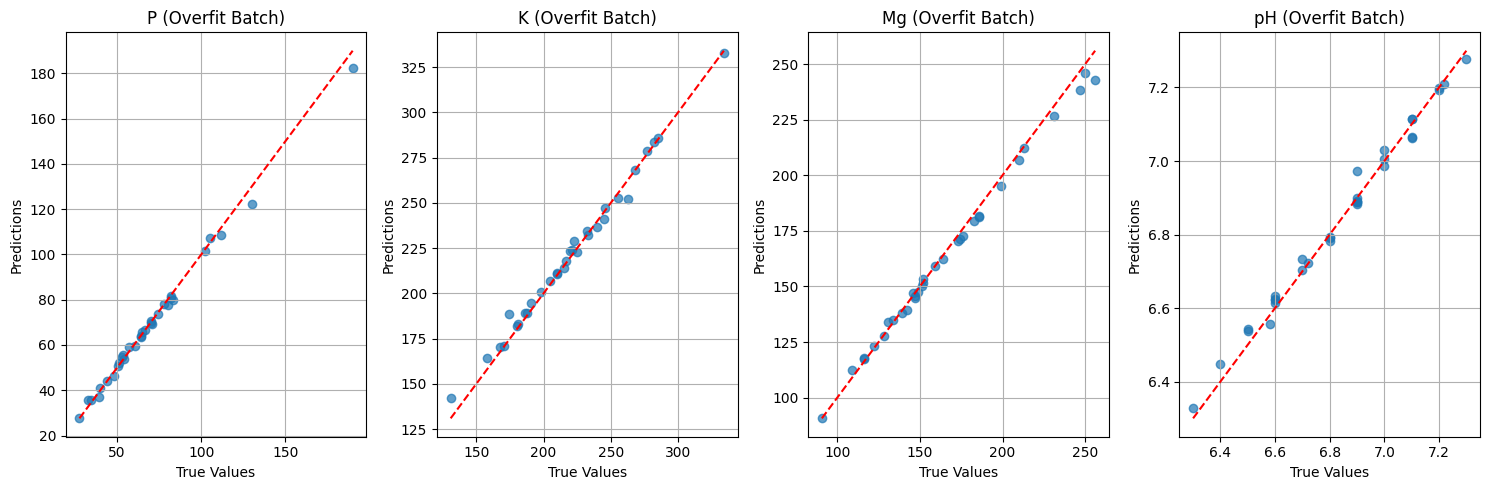

In [30]:

plt.figure(figsize=(15, 5))

metrics = ['P', 'K', 'Mg', 'pH']
for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i + 1) # 1 row, 4 columns
    plt.scatter(unscaled_true_values[:, i], unscaled_predictions[:, i], alpha=0.7)
    plt.plot([min(unscaled_true_values[:, i]), max(unscaled_true_values[:, i])],
             [min(unscaled_true_values[:, i]), max(unscaled_true_values[:, i])],
             'r--') # Red dashed line for ideal prediction
    plt.title(f'{metric} (Overfit Batch)')
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.grid(True)

plt.tight_layout()
plt.show()


# **Training loop**

In [31]:
import os
import torch
from tqdm import tqdm

def train_with_early_stopping(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,            # ReduceLROnPlateau expected
    criterion,
    device,
    epochs=120,
    warmup_epochs=5,
    patience=20,
    save_path="best_hyperspectral_model.pth",
    use_amp=False, # Re-introduced use_amp parameter
    max_grad_norm=1.0,
    wandb_run=None
):
    # initial LRs per param_group (order must match how optimizer was created)
    initial_lrs = [pg['lr'] for pg in optimizer.param_groups]

    best_val_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(epochs):
        # ---------- TRAIN ----------
        model.train()
        train_running_loss = 0.0
        train_samples = 0

        # linear warmup
        if epoch < warmup_epochs:
            warmup_factor = (epoch + 1) / float(warmup_epochs)
            for i, pg in enumerate(optimizer.param_groups):
                pg['lr'] = initial_lrs[i] * warmup_factor

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for xb, nv_b, yb in loop:
            xb   = xb.to(device, non_blocking=True)
            nv_b = nv_b.to(device, non_blocking=True)
            yb   = yb.to(device, non_blocking=True)

            optimizer.zero_grad()

            preds = model(xb, nv_b)
            loss = criterion(preds, yb)

            loss.backward()

            # Calculate gradient norm before clipping
            #total_norm = torch.sqrt(
            #    sum(p.grad.detach().norm(2)**2 for p in model.parameters() if p.grad is not None)
            #)

            # for name, p in model.named_parameters():
            #   if p.grad is not None:
            #       print(name, p.grad.abs().mean().item())
            #       break

            # Clip gradient
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            optimizer.step()

            bsz = xb.size(0)
            train_running_loss += loss.item() * bsz
            train_samples += bsz

            loop.set_postfix(
                train_loss=loss.item(),
                # grad_norm=total_norm.item(), # Log gradient norm
                lr_spectral_reducer=optimizer.param_groups[0]['lr'],
                lr_backbone=optimizer.param_groups[1]['lr'],
                lr_head=optimizer.param_groups[2]['lr']
            )

        train_loss = train_running_loss / max(1, train_samples)

        # ---------- VALIDATION ----------
        model.eval()
        val_running_loss = 0.0
        val_samples = 0
        # optional threshold for logging outlier batches (set after first epoch if desired)
        outlier_threshold = None

        with torch.no_grad():
            for i, (xv, nv_v, yv) in enumerate(val_loader):
                xv   = xv.to(device, non_blocking=True)
                nv_v = nv_v.to(device, non_blocking=True)
                yv   = yv.to(device, non_blocking=True)

                vpreds = model(xv, nv_v)
                vloss = criterion(vpreds, yv)

                bsz = xv.size(0)
                val_running_loss += vloss.item() * bsz
                val_samples += bsz

                # detect very large batch losses for debugging
                if outlier_threshold is not None and vloss.item() > outlier_threshold:
                    print(f"[DEBUG] Large val batch loss epoch {epoch+1} batch {i}: {vloss.item():.4f}")
                    # optionally save xv, yv, vpreds.cpu() for inspection

        val_loss = val_running_loss / max(1, val_samples)

        # ---------- SCHEDULER ----------
        # Skip scheduler during warmup to prevent premature LR reduction
        if epoch >= warmup_epochs:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # ---------- LOGGING ----------
        current_lrs = [pg['lr'] for pg in optimizer.param_groups]
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - spectral reducer LR: {current_lrs[0]:.6f} - backbone LR: {current_lrs[1]:.6f} - head LR: {current_lrs[2]:.6f}")

        if wandb_run is not None:
            wandb_run.log({
                "train_loss": train_loss,
                "val_loss": val_loss,
                "epoch": epoch + 1,
                "lr_spectral_reducer": current_lrs[0],
                "lr_backbone": current_lrs[1],
                "lr_head": current_lrs[2]
                #"grad_norm": total_norm.item() # Log gradient norm to wandb
            })

        # ---------- EARLY STOPPING & CHECKPOINT ----------
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            # save full checkpoint
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict() if hasattr(scheduler, "state_dict") else None,
                "val_loss": val_loss,
            }, save_path)
            print(f"Saved best model (val_loss={val_loss:.4f})")
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                break

    # load best model if exists
    if os.path.exists(save_path):
        ckpt = torch.load(save_path, map_location=device)
        model.load_state_dict(ckpt["model_state_dict"])
    return model

In [41]:
import torch.nn as nn
import timm

# ----- Model -----
model = HyperspectralRegressor(
    reduced_in_channels = 3,   # reduced channels
    n_outputs = 4,      # P, K, Mg, pH
    backbone_name = "maxvit_tiny_tf_224",
    pretrained = True
)

model = model.to(device);

# ----- Optimizer -----
optimizer = optim.AdamW([
    {"params": model.spectral_reducer.parameters(), "lr": 1e-3},
    {"params": model.backbone.parameters(), "lr": 1e-5},
    {"params": model.regressor.parameters(), "lr": 1e-3},
], weight_decay=1e-4)

# ----- Loss -----
criterion = nn.MSELoss()
#criterion = nn.SmoothL1Loss(beta=1.0)

# ----- Scheduler -----
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=6,
    min_lr=1e-6
)

# ----- Hyperparameters -----
epochs = 90
patience = 12  # Increased early stopping patience
warmup_epochs = 10 # Number of epochs for warm-up

# ----- Initialize wandb -----
# Initializing Weights & Biases for experiment tracking.
wandb.init(
    project="37 - maxvit_tiny_tf_224 (pretrained=true), size feature added, no gauss noise",
    config={
        "learning_rate_backbone": 1e-5, # Updated in config
        "learning_rate_head": 1e-3, # Updated in config
        "learning_rate_reduced": 1e-3, # Updated in config
        "weight_decay": 1e-4,
        "epochs": epochs,
        "batch_size": 32,
        "optimizer": "AdamW",
        "criterion": "MSELoss",
        "backbone": "maxvit_tiny_tf_224",
        "1x1_conv_filters": 3,
        "scheduler": "ReduceLROnPlateau",
        "scheduler_factor": 0.3,
        "scheduler_patience": 6,
        "min_lr": 1e-6,
        "warmup_epochs": warmup_epochs,
        "early_stopping_patience": patience,
        "use_amp": "False",
        "gaussian_noise_enabled": "False",
        "augmentation": "True"
    }
)
# Log a note to wandb about this run's configuration
wandb.run.log({"note": "This run uses: (1) maxvit_tiny_tf_224 backbone (pretrained=true) - augmentation enabled, (2) 1x1 conv used, (3) MSELoss, (4)padding instead of resize (!), (5) batch size 32, (6) Automatic Mixed Precision disabled, (7) Global normalization (!)"})

In [42]:
train_with_early_stopping(
    model = model,
    train_loader = train_loader,
    val_loader = val_loader,
    optimizer = optimizer,
    scheduler = scheduler,
    criterion = criterion,
    device = device,
    epochs   = epochs,
    warmup_epochs = warmup_epochs,
    patience = patience,
    save_path="best_hyperspectral_model.pth",
    max_grad_norm=1.0,
    wandb_run=wandb.run
)

# ----- Finish wandb -----
wandb.finish()

Epoch 1/90 - Train Loss: 0.9976 - Val Loss: 1.1875 - spectral reducer LR: 0.000100 - backbone LR: 0.000001 - head LR: 0.000100
Saved best model (val_loss=1.1875)


Epoch 2/90 - Train Loss: 0.9758 - Val Loss: 1.1582 - spectral reducer LR: 0.000200 - backbone LR: 0.000002 - head LR: 0.000200
Saved best model (val_loss=1.1582)


Epoch 3/90 - Train Loss: 0.9526 - Val Loss: 1.1419 - spectral reducer LR: 0.000300 - backbone LR: 0.000003 - head LR: 0.000300
Saved best model (val_loss=1.1419)


Epoch 4/90 - Train Loss: 0.9445 - Val Loss: 1.1372 - spectral reducer LR: 0.000400 - backbone LR: 0.000004 - head LR: 0.000400
Saved best model (val_loss=1.1372)


Epoch 5/90 - Train Loss: 0.9362 - Val Loss: 1.1175 - spectral reducer LR: 0.000500 - backbone LR: 0.000005 - head LR: 0.000500
Saved best model (val_loss=1.1175)


...

Epoch 61/90 - Train Loss: 0.6108 - Val Loss: 1.0194 - spectral reducer LR: 0.000300 - backbone LR: 0.000003 - head LR: 0.000300


Epoch 62/90 - Train Loss: 0.6061 - Val Loss: 1.0314 - spectral reducer LR: 0.000300 - backbone LR: 0.000003 - head LR: 0.000300


Epoch 63/90 - Train Loss: 0.6061 - Val Loss: 1.0622 - spectral reducer LR: 0.000300 - backbone LR: 0.000003 - head LR: 0.000300


Epoch 64/90 - Train Loss: 0.6251 - Val Loss: 1.0214 - spectral reducer LR: 0.000300 - backbone LR: 0.000003 - head LR: 0.000300
Early stopping at epoch 64 (no improvement for 12 epochs)


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
lr_backbone,▁▂▃▄▅▆▇████████████████████████████▂▂▂▂▂
lr_head,▁▂▃▅▇████████████████████████████████▂▂▂
lr_spectral_reducer,▁▂▃▃▄▆▆█████████████████████████████▃▃▃▃
train_loss,██▇▇▇▆▆▆▆▅▅▅▅▄▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁
val_loss,█▇▆▆▆▅▅▄▄▄▄▄▃▃▂▃▃▃▂▃▂▂▂▂▃▂▂▂▁▁▂▂▁▃▂▃▃▂▂▂
epoch,64
lr_backbone,0.0
lr_head,0.0003
lr_spectral_reducer,0.0003
note,This run uses: (1) m...


In [43]:
# ----- Load best model -----
checkpoint = torch.load("best_hyperspectral_model.pth")
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

## **Evaluate results in comparision to the Baseline Regressor.**

In [44]:
class BaselineRegressor:
    """
    Baseline regressor, which calculates the mean value of the target from the training
    data and returns it for each testing sample.
    """
    def __init__(self):
        self.mean = 0

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        self.mean = np.mean(y_train, axis=0)
        self.classes_count = y_train.shape[1]
        return self

    def predict(self, X_test: np.ndarray):
        return np.full((len(X_test), self.classes_count), self.mean)


class SpectralCurveFiltering():
    """
    Create a histogram (a spectral curve) of a 3D cube, using the merge_function
    to aggregate all pixels within one band. The return array will have
    the shape of [CHANNELS_COUNT]
    """

    def __init__(self, merge_function = np.mean):
        self.merge_function = merge_function

    def __call__(self, sample: np.ndarray):
        return self.merge_function(sample, axis=(1, 2))

In [45]:
def evaluate_dl_model(model, test_loader, scaler_y, device):
    """Evaluates the deep learning model on the local test dataset."""
    model.eval()
    test_predictions_scaled = []
    y_true_scaled = [] # To collect the true scaled labels from the DataLoader

    with torch.no_grad():
        for X_batch_test, nv_batch, y_batch_true_scaled in test_loader:
            X_batch_test = X_batch_test.to(device)
            nv_batch = nv_batch.to(device)
            preds_batch = model(X_batch_test, nv_batch)
            test_predictions_scaled.append(preds_batch.cpu().numpy())
            y_true_scaled.append(y_batch_true_scaled.cpu().numpy())

    y_test_scaled_pred = np.vstack(test_predictions_scaled)
    y_test_scaled_true = np.vstack(y_true_scaled)

    # Inverse transform predictions and true values
    y_test_pred = scaler_y.inverse_transform(y_test_scaled_pred)
    y_test_true_from_loader = scaler_y.inverse_transform(y_test_scaled_true)

    model_mse_targets = np.mean((y_test_true_from_loader - y_test_pred)**2, axis=0)
    return y_test_pred, y_test_true_from_loader, model_mse_targets

def evaluate_baseline_regressor(baseline_regressor, X_test_filtered, y_test_true):
    """Evaluates the baseline regressor on the test dataset."""
    baseline_preds_test = baseline_regressor.predict(X_test_filtered)
    baseline_mse_targets = np.mean((y_test_true - baseline_preds_test)**2, axis=0)
    return baseline_preds_test, baseline_mse_targets

def calculate_and_print_results(model_mse_targets, baseline_mse_targets, y_test_true, y_test_pred, baseline_preds_test):
    """Calculates and prints the challenge score and per-target comparison, and plots results."""
    challenge_score = np.mean(model_mse_targets / baseline_mse_targets)

    target_names = ["P", "K", "Mg", "pH"]
    print("Per-target comparison (on local test set from training data):")
    for i, name in enumerate(target_names):
        print(f"{name}: Model MSE = {model_mse_targets[i]:.4f}, Baseline MSE = {baseline_mse_targets[i]:.4f}, Normalized = {model_mse_targets[i]/baseline_mse_targets[i]:.4f}")

    print(f"\nChallenge normalized score (lower is better, on local test set): {challenge_score:.4f}")

    # Plotting
    plt.figure(figsize=(15, 5))
    for i, metric in enumerate(target_names):
        plt.subplot(1, 4, i + 1)
        plt.scatter(y_test_true[:, i], y_test_pred[:, i], alpha=0.7, label='DL Model Predictions')
        plt.scatter(y_test_true[:, i], baseline_preds_test[:, i], alpha=0.7, label='Baseline Predictions', marker='x')
        min_val = min(y_test_true[:, i].min(), y_test_pred[:, i].min(), baseline_preds_test[:, i].min())
        max_val = max(y_test_true[:, i].max(), y_test_pred[:, i].max(), baseline_preds_test[:, i].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Prediction')
        plt.title(f'{metric} Predictions')
        plt.xlabel('True Values')
        plt.ylabel('Predictions')
        plt.grid(True)
        plt.legend()
    plt.tight_layout()
    plt.show()

In [46]:
# Get true y values from the local test dataset (inverse-scaled)
y_test_scaled_true = np.array([test_dataset[i][2].numpy() for i in range(len(test_dataset))])
y_test_true = scaler_y.inverse_transform(y_test_scaled_true)

In [47]:
# We need the original unscaled, non-PCA data for the baseline regressor
X_test_nonpca = [X_train_full_data[i] for i in test_indices]

# We need to apply SpectralCurveFiltering to the original X_test_nonpca for the baseline regressor
filtering = SpectralCurveFiltering()
X_test_filtered = np.array([filtering(cube[0].cpu().numpy()) for cube in X_test_nonpca]) # Accessing the image tensor from tuple

# Train a new baseline regressor on the combined training and validation splits
# Combine train and validation indices
combined_train_val_indices = train_indices.tolist() + val_indices.tolist() # Convert to list for concatenation

# Get the original unscaled, non-PCA data for the baseline training
X_combined_train_val_nonpca = [X_train_full_data[i] for i in combined_train_val_indices]
y_combined_train_val_nonpca = y_train[combined_train_val_indices] # Use unscaled y_train for baseline training

X_combined_train_val_filtered = np.array([filtering(cube[0].cpu().numpy()) for cube in X_combined_train_val_nonpca]) # Accessing the image tensor from tuple

In [48]:
baseline_reg_current = BaselineRegressor() # Initialize a new baseline regressor
baseline_reg_current = baseline_reg_current.fit(X_combined_train_val_filtered, y_combined_train_val_nonpca)

baseline_preds_test = baseline_reg_current.predict(X_test_filtered)

In [49]:
# Load the best model weights
checkpoint = torch.load("best_hyperspectral_model.pth")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Iterate through the local test loader to get predictions
test_predictions_scaled = []

# # Create a DataLoader for the local test dataset
# local_test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

with torch.no_grad():
    for X_batch_test, nv_batch, _ in test_loader:
        X_batch_test = X_batch_test.to(next(model.parameters()).device)
        nv_batch = nv_batch.to(next(model.parameters()).device)
        preds_batch = model(X_batch_test, nv_batch)
        test_predictions_scaled.append(preds_batch.cpu().numpy())

y_test_scaled_pred = np.vstack(test_predictions_scaled) # predicted in scaled units

# Convert to numpy and inverse scale to original units
y_test_pred = scaler_y.inverse_transform(y_test_scaled_pred)

In [50]:
# -----------------------------
# Compute MSE per target
# -----------------------------
model_mse_targets = np.mean((y_test_true - y_test_pred)**2, axis=0)
baseline_mse_targets = np.mean((y_test_true - baseline_preds_test)**2, axis=0)

# Compute normalized score (challenge metric)
challenge_score = np.mean(model_mse_targets / baseline_mse_targets)

# -----------------------------
# Print per-target comparison
# -----------------------------
target_names = ["P", "K", "Mg", "pH"]
print("Per-target comparison (on local test set from training data):")
for i, name in enumerate(target_names):
    print(f"{name}: Model MSE = {model_mse_targets[i]:.4f}, Baseline MSE = {baseline_mse_targets[i]:.4f}, Normalized = {model_mse_targets[i]/baseline_mse_targets[i]:.4f}")

print(f"\nChallenge normalized score (lower is better, on local test set): {challenge_score:.4f}")

Per-target comparison (on local test set from training data):
P: Model MSE = 937.5502, Baseline MSE = 956.1005, Normalized = 0.9806
K: Model MSE = 2504.2683, Baseline MSE = 3448.3214, Normalized = 0.7262
Mg: Model MSE = 1293.0944, Baseline MSE = 1448.3911, Normalized = 0.8928
pH: Model MSE = 0.0648, Baseline MSE = 0.0677, Normalized = 0.9577

Challenge normalized score (lower is better, on local test set): 0.8893


Per-target comparison (on local test set from training data):
P: Model MSE = 937.5502, Baseline MSE = 956.1005, Normalized = 0.9806
K: Model MSE = 2504.2683, Baseline MSE = 3448.3214, Normalized = 0.7262
Mg: Model MSE = 1293.0944, Baseline MSE = 1448.3911, Normalized = 0.8928
pH: Model MSE = 0.0648, Baseline MSE = 0.0677, Normalized = 0.9577

Challenge normalized score (lower is better, on local test set): 0.8893


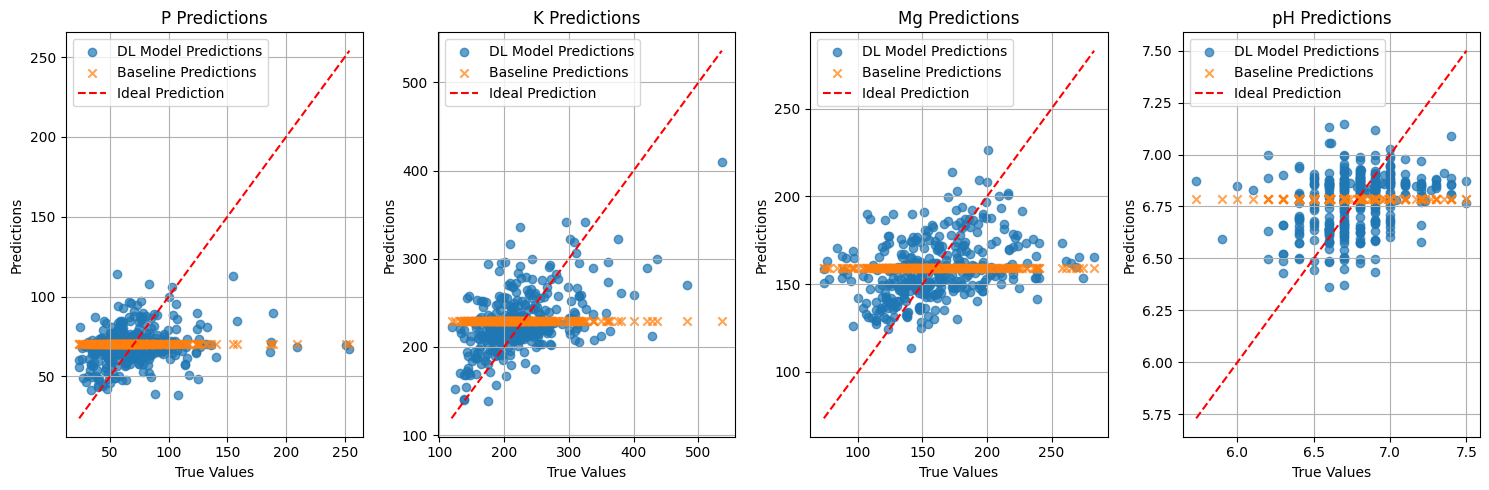

In [51]:
# Load the best model weights for the deep learning model
#model.load_state_dict(torch.load("best_hyperspectral_model.pth"))

# Evaluate the deep learning model
dl_y_test_pred, dl_y_test_true, dl_model_mse_targets = evaluate_dl_model(model, test_loader, scaler_y, device)

# Evaluate the baseline regressor (using the globally available y_test_true from inverse scaling test_dataset labels)
baseline_y_test_pred, baseline_mse_targets = evaluate_baseline_regressor(baseline_reg_current, X_test_filtered, y_test_true)

# Calculate and print combined results, including plotting
calculate_and_print_results(dl_model_mse_targets, baseline_mse_targets, y_test_true, dl_y_test_pred, baseline_y_test_pred)

In [52]:
def display_predictions_table(model, test_loader, scaler_y, device):
    """Displays the model's predictions against ground truth values in a tabular form (unscaled)."""
    model.eval()  # Set the model to evaluation mode
    all_predictions_scaled = []
    all_true_values_scaled = []

    with torch.no_grad():
        for X_batch, nv_batch, y_batch_true_scaled in test_loader:
            X_batch = X_batch.to(device)
            nv_batch = nv_batch.to(device)
            preds_batch = model(X_batch, nv_batch)
            all_predictions_scaled.append(preds_batch.cpu().numpy())
            all_true_values_scaled.append(y_batch_true_scaled.cpu().numpy())

    # Concatenate all batches
    y_predictions_scaled = np.vstack(all_predictions_scaled)
    y_true_scaled = np.vstack(all_true_values_scaled)

    # Inverse transform to get original values
    y_predictions_unscaled = scaler_y.inverse_transform(y_predictions_scaled)
    y_true_unscaled = scaler_y.inverse_transform(y_true_scaled)

    # Create a DataFrame for display
    target_names = ["P", "K", "Mg", "pH"]

    # To ensure consistent number of samples, we'll just take a few examples from the test set
    num_samples_to_display = min(10, len(y_predictions_unscaled))

    # Correctly build the dictionary for DataFrame
    data_for_df = {}
    for i, name in enumerate(target_names):
        data_for_df[f'True {name}'] = y_true_unscaled[:num_samples_to_display, i]
        data_for_df[f'Pred {name}'] = y_predictions_unscaled[:num_samples_to_display, i]

    df_display = pd.DataFrame(data_for_df)

    print(f"\nSample of {num_samples_to_display} Predictions vs. True Values (Unscaled):")
    display(df_display)

# Example usage of the function:
display_predictions_table(model, test_loader, scaler_y, device)


Sample of 10 Predictions vs. True Values (Unscaled):


,True P,Pred P,True K,Pred K,True Mg,Pred Mg,True pH,Pred pH
0,64.599998,61.781399,243.0,229.488266,184.000000,148.066467,6.50,6.634605
1,36.099998,69.605667,193.0,218.931625,77.200005,152.929016,5.73,6.872392
2,56.400002,69.127937,213.0,208.453583,154.000000,156.039459,6.70,6.506196
3,46.500000,83.440659,146.0,257.761230,116.000000,134.003586,6.90,6.907842
4,57.599998,79.012711,234.0,278.987640,167.000000,184.024445,6.40,6.696898
5,68.400002,71.565552,230.0,212.729324,220.000000,155.739075,6.80,6.876925
6,35.500000,67.048386,132.0,220.311554,120.000000,131.553055,6.80,6.867193
7,96.199997,73.367661,226.0,278.385834,140.000000,165.210510,6.80,6.768641
8,45.400002,53.475620,209.0,272.418304,143.000000,177.072617,6.80,6.822126
9,123.000000,65.076599,363.0,218.502029,195.000000,158.273331,6.96,6.899446


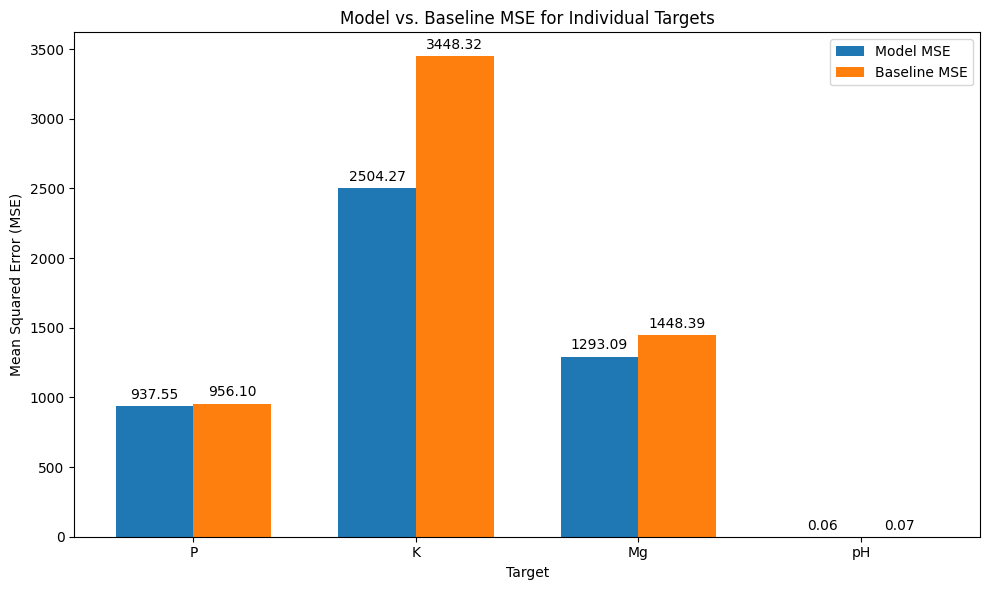

In [53]:
import matplotlib.pyplot as plt
import numpy as np

target_names = ["P", "K", "Mg", "pH"]

# Get the MSEs from the kernel state
# Assuming model_mse_targets and baseline_mse_targets are available from previous execution
model_mse_targets = np.array(model_mse_targets) # Ensure it's a numpy array for indexing
baseline_mse_targets = np.array(baseline_mse_targets) # Ensure it's a numpy array for indexing

x = np.arange(len(target_names))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, model_mse_targets, width, label='Model MSE')
rects2 = ax.bar(x + width/2, baseline_mse_targets, width, label='Baseline MSE')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Target')
ax.set_ylabel('Mean Squared Error (MSE)')
ax.set_title('Model vs. Baseline MSE for Individual Targets')
ax.set_xticks(x)
ax.set_xticklabels(target_names)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

## Generate submission file

In [ ]:
import gc

del train_dataset
del val_dataset
del test_dataset
del train_loader
del val_loader
del test_loader

gc.collect()

NameError: name 'train_dataset' is not defined

In [ ]:
# import torch
# torch.cuda.empty_cache()

In [ ]:
X_test_submission = load_data("/content/test_data/test")

In [ ]:


test_dataset_submission  = NPZDataset(X_test_submission, augment=False, global_means=global_means, global_stds=global_stds)
test_submission_loader  = DataLoader(test_dataset_submission, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
model.eval() # Set the model to evaluation mode

submission_predictions_scaled = []

with torch.no_grad():
    for X_batch_submission, nv_batch in test_submission_loader:
        # X_batch_submission contains only features, no labels for submission dataset
        X_batch_submission = X_batch_submission.to(next(model.parameters()).device)
        nv_batch = nv_batch.to(next(model.parameters()).device)
        preds_batch = model(X_batch_submission, nv_batch)
        submission_predictions_scaled.append(preds_batch.cpu().numpy())

y_submission_scaled_pred = np.vstack(submission_predictions_scaled)

# Inverse transform predictions to get original values
y_submission_pred = scaler_y.inverse_transform(y_submission_scaled_pred)

# Create submission DataFrame
submission = pd.DataFrame(data=y_submission_pred, columns=["P", "K", "Mg", "pH"])

# Save to CSV
submission.to_csv("submission.csv", index_label="sample_index")
print("Submission file 'submission.csv' created successfully!")

Submission file 'submission.csv' created successfully!
